<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/temporal_balance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

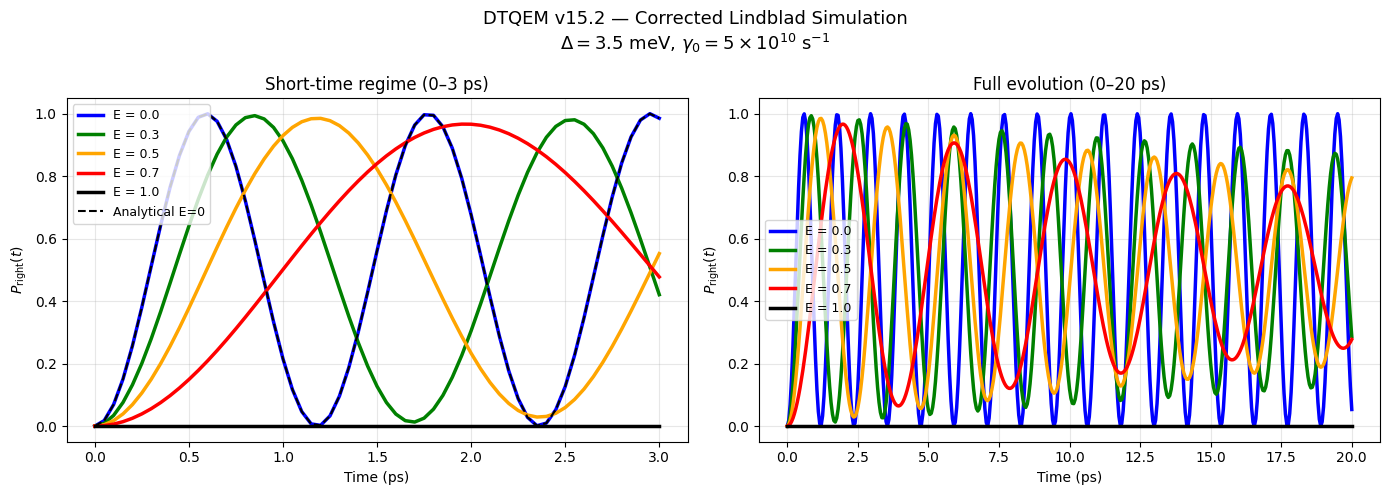


=== DTQEM v15.2 — P_right at t = 20 ps ===
   E_ext |    P_right | Note
----------------------------------------
     0.0 |     0.0532 | Free Rabi
     0.3 |     0.2872 | Partial decoherence
     0.5 |     0.7943 | Sync point
     0.7 |     0.2774 | Near-Zeno
     1.0 |     0.0000 | Zeno freeze


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ============================================================
# 1. الثوابت الأساسية
# ============================================================
hbar = 1.0545718e-34          # J·s
eV = 1.60217662e-19           # J/eV
Delta_meV = 3.5               # meV
Delta_J = Delta_meV * 1e-3 * eV   # ≈ 5.607e-22 J
gamma0 = 5e10                 # 1/s

t_max_ps = 20.0
t_max = t_max_ps * 1e-12
dt = 0.05e-12
t_arr = np.arange(0, t_max + dt, dt)
steps = len(t_arr)

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.eye(2, dtype=complex)

# ============================================================
# 2. بناء الليوفيليان
# ============================================================
def build_liouvillian(H, L_list):
    Lv = -1j/hbar * (np.kron(H, I) - np.kron(I, H.T))
    for Lk in L_list:
        Lk_dag = Lk.conj().T
        Lv += np.kron(Lk, Lk.conj())
        Lk_dag_Lk = Lk_dag @ Lk
        Lv += -0.5 * (np.kron(Lk_dag_Lk, I) + np.kron(I, Lk_dag_Lk.T))
    return Lv

# ============================================================
# 3. المحاكاة (محسّنة)
# ============================================================
def run_simulation(E_ext):
    H_eff = (Delta_J / 2.0) * (1.0 - E_ext) * sx
    L_ops = []
    if E_ext > 0:
        L_ops.append(np.sqrt(gamma0 * E_ext) * sz)

    L = build_liouvillian(H_eff, L_ops)
    prop = expm(L * dt)               # حساب مرة واحدة فقط

    rho = np.array([[1, 0], [0, 0]], dtype=complex)
    P_right = np.zeros(steps)

    for i in range(steps):
        if i > 0:
            rho_vec = prop @ rho.flatten('C')
            rho = rho_vec.reshape(2, 2)
            rho = 0.5 * (rho + rho.conj().T)   # تناسق هيرميتي فقط
        P_right[i] = rho[1, 1].real
    return P_right

# ============================================================
# 4. التشغيل والعرض
# ============================================================
E_values = [0.0, 0.3, 0.5, 0.7, 1.0]
colors = ['blue', 'green', 'orange', 'red', 'black']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# اللوحة الأولى: الزمن القصير (0-3 ps) مع منحنى تحليلي للتحقق
for E, col in zip(E_values, colors):
    P = run_simulation(E)
    mask = t_arr <= 3e-12
    axes[0].plot(t_arr[mask] * 1e12, P[mask], color=col, lw=2.5, label=f'E = {E}')

# منحنى تحليلي لـ E=0 (Rabi الخالص)
P_ana = np.sin((Delta_J / hbar) * t_arr / 2) ** 2
mask = t_arr <= 3e-12
axes[0].plot(t_arr[mask] * 1e12, P_ana[mask], 'k--', lw=1.5, label='Analytical E=0')
axes[0].set_title('Short-time regime (0–3 ps)', fontsize=12)
axes[0].set_xlabel('Time (ps)')
axes[0].set_ylabel('$P_{\\mathrm{right}}(t)$')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# اللوحة الثانية: الزمن الكامل (0-20 ps)
for E, col in zip(E_values, colors):
    P = run_simulation(E)
    axes[1].plot(t_arr * 1e12, P, color=col, lw=2.5, label=f'E = {E}')
axes[1].set_title('Full evolution (0–20 ps)', fontsize=12)
axes[1].set_xlabel('Time (ps)')
axes[1].set_ylabel('$P_{\\mathrm{right}}(t)$')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('DTQEM v15.2 — Corrected Lindblad Simulation\n'
             r'$\Delta=3.5$ meV, $\gamma_0=5\times10^{10}$ s$^{-1}$', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 5. جدول النتائج عند t = 20 ps
# ============================================================
print("\n=== DTQEM v15.2 — P_right at t = 20 ps ===")
print(f"{'E_ext':>8} | {'P_right':>10} | {'Note'}")
print("-" * 40)
notes = {0.0: "Free Rabi", 0.3: "Partial decoherence",
         0.5: "Sync point", 0.7: "Near-Zeno", 1.0: "Zeno freeze"}
for E in E_values:
    P = run_simulation(E)
    print(f"{E:>8.1f} | {P[-1]:>10.4f} | {notes[E]}")